In [83]:
# PARTIE 1 : IMPORTATION ET EXPLORATION

# 1. Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique pour les graphiques
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Charger l'ensemble de données de séries temporelles
# Fichier 'household_power_consumption.txt' avec séparateur ';' et '?' comme NaN
try:
    # Load the dataset, replacing '?' with NaN and parsing dates
    df_raw = pd.read_csv(
        'household_power_consumption.txt',
        sep=';',
        na_values=['?'],
        low_memory=False
    )

    # Combine Date and Time columns into a single datetime column and set as index
    df_raw['DateTime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'], format='%d/%m/%Y %H:%M:%S')
    df_raw = df_raw.set_index('DateTime')
    df_raw = df_raw.drop(columns=['Date', 'Time'])

    # Convert all other columns to numeric, coercing errors to NaN
    for col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

    print("Fichier 'household_power_consumption.txt' chargé avec succès !\n")

except FileNotFoundError:
    print("Erreur : Le fichier 'household_power_consumption.txt' est introuvable. Veuillez vous assurer qu'il est dans le bon répertoire.")
    # Optionally, you can generate dummy data here if needed for demonstration when the file is missing
    # For now, we'll stop execution if the file is not found as it's critical for the exercise.
    df_raw = pd.DataFrame() # Create an empty DataFrame to prevent further errors

# 3. Afficher les premières lignes de l'ensemble de données
print("--- Aperçu des 5 premières lignes du jeu de données ---")
print(df_raw.head())
print("\n" + "="*50 + "\n")

# 4. Vérifier la structure et le type de données de chaque colonne
print("--- Structure globale du jeu de données (Shape) ---")
print(f"Nombre de lignes (observations) : {df_raw.shape[0]}")
print(f"Nombre de colonnes (variables)   : {df_raw.shape[1]}")
print("\n" + "="*50 + "\n")

print("--- Informations détaillées et types de données ---")
print(df_raw.info())

Erreur : Le fichier 'household_power_consumption.txt' est introuvable. Veuillez vous assurer qu'il est dans le bon répertoire.
--- Aperçu des 5 premières lignes du jeu de données ---
Empty DataFrame
Columns: []
Index: []


--- Structure globale du jeu de données (Shape) ---
Nombre de lignes (observations) : 0
Nombre de colonnes (variables)   : 0


--- Informations détaillées et types de données ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame
None


In [52]:

# PARTIE 2 : GESTION DES VALEURS MANQUANTES

print("--- 1. Identification des valeurs manquantes par colonne ---")
# Calcul du total et du pourcentage de valeurs manquantes par colonne
missing_count = df_raw.isnull().sum()
missing_percentage = (df_raw.isnull().sum() / len(df_raw)) * 100

# Création d'un tableau récapitulatif pour l'affichage
missing_summary = pd.DataFrame({
    'Valeurs Manquantes': missing_count,
    'Pourcentage (%)': missing_percentage
})
print(missing_summary)
print("\n" + "="*50 + "\n")


print("--- 2. Imputation des valeurs manquantes par la moyenne ---")
# Copie de sauvegarde du dataset original avant modification
df_cleaned = df_raw.copy()

# Remplacement des valeurs manquantes par la moyenne de chaque colonne respectives
for colonne in df_cleaned.columns:
    if df_cleaned[colonne].isnull().any():
        colonne_mean = df_cleaned[colonne].mean()
        df_cleaned[colonne] = df_cleaned[colonne].fillna(colonne_mean)
        print(f"Remplacement effectué pour '{colonne}' avec sa moyenne : {colonne_mean:.2f}")

print("\n" + "="*50 + "\n")


print("--- 3. Vérification finale du jeu de données ---")
# Nouvelle vérification pour s'assurer que le compteur est à zéro partout
remaining_missing = df_cleaned.isnull().sum().sum()

if remaining_missing == 0:
    print(f"Succès ! Il reste exactement {remaining_missing} valeur manquante dans le jeu de données.")
    print("Le jeu de données est désormais propre et prêt pour la normalisation.")
else:
    print(f"Attention : Il reste encore {remaining_missing} valeurs manquantes.")


--- 1. Identification des valeurs manquantes par colonne ---
        Valeurs Manquantes  Pourcentage (%)
Open                     0              0.0
High                     0              0.0
Low                      0              0.0
Close                    0              0.0
Volume                   0              0.0


--- 2. Imputation des valeurs manquantes par la moyenne ---


--- 3. Vérification finale du jeu de données ---
Succès ! Il reste exactement 0 valeur manquante dans le jeu de données.
Le jeu de données est désormais propre et prêt pour la normalisation.


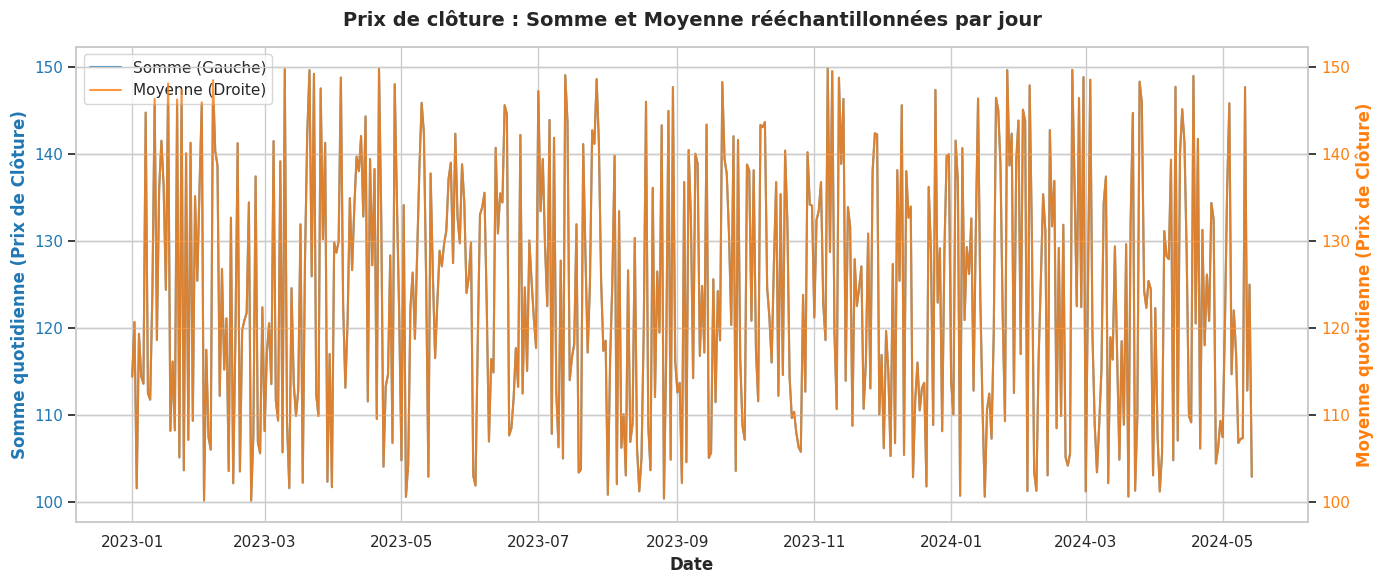

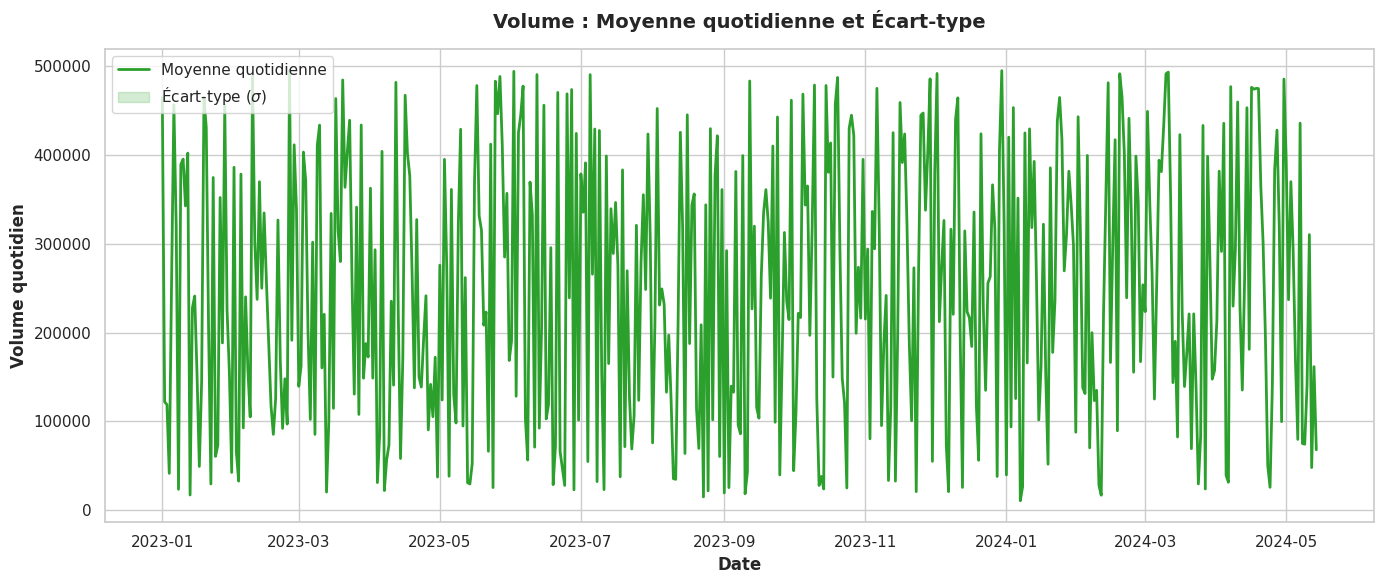

In [54]:

# PARTIE 3 : VISUALISATION DES DONNÉES

import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Note : Nous supposons que df_cleaned possède un index de type Datetime.
# Si ce n'est pas le chef, décommentez la ligne suivante :
# df_cleaned.index = pd.to_datetime(df_cleaned.index)


# 1. RÉÉCHANTILLONNAGE DE 'Close' (prix de clôture)


# Rééchantillonnage quotidien (fréquence 'D' pour Day)
gap_daily_sum = df_cleaned['Close'].resample('D').sum() # Using 'Close' price
gap_daily_mean = df_cleaned['Close'].resample('D').mean() # Using 'Close' price

# Tracé du graphique (Somme vs Moyenne)
fig, ax1 = plt.subplots()

# Axe principal pour la Somme (à gauche)
color = '#1f77b4'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Somme quotidienne (Prix de Clôture)', color=color, fontweight='bold')
line1 = ax1.plot(gap_daily_sum.index, gap_daily_sum.values, color=color, label='Somme (Gauche)', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)

# Axe secondaire pour la Moyenne (à droite)
ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Moyenne quotidienne (Prix de Clôture)', color=color, fontweight='bold')
line2 = ax2.plot(gap_daily_mean.index, gap_daily_mean.values, color=color, label='Moyenne (Droite)', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color)

# Gestion de la légende unique
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Prix de clôture : Somme et Moyenne rééchantillonnées par jour', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# 2. RÉÉCHANTILLONNAGE DE 'Volume'

# Rééchantillonnage quotidien (Moyenne et Écart-type)
gi_daily_mean = df_cleaned['Volume'].resample('D').mean() # Using 'Volume'
gi_daily_std = df_cleaned['Volume'].resample('D').std() # Using 'Volume'

# Tracé du graphique (Moyenne avec zone d'écart-type)
plt.figure()

plt.plot(gi_daily_mean.index, gi_daily_mean.values, color='#2ca02c', label='Moyenne quotidienne', linewidth=2)

# Remplissage de la zone représentant l'écart-type (Moyenne +/- Écart-type)
plt.fill_between(
    gi_daily_mean.index,
    gi_daily_mean.values - gi_daily_std.values,
    gi_daily_mean.values + gi_daily_std.values,
    color='#2ca02c',
    alpha=0.2,
    label='Écart-type ($\\sigma$)'
)

plt.xlabel('Date', fontweight='bold')
plt.ylabel('Volume quotidien', fontweight='bold')
plt.title('Volume : Moyenne quotidienne et Écart-type', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [69]:
# PARTIE 4 : PRÉTRAITEMENT DES DONNÉES POUR LSTM

import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

# 1. Sélection et Normalisation de la variable cible
# Nous choisissons 'Close' comme exemple de série à prédire
target_series = df_cleaned[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(target_series)

# 2. Division de l'ensemble de données (Entraînement et Test)
# Pour les séries temporelles, le découpage doit être chronologique (pas de shuffle)
train_size = int(len(scaled_data) * 0.80)  # 80% Entraînement, 20% Test
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Taille de l'ensemble d'entraînement : {len(train_data)} observations")
print(f"Taille de l'ensemble de test         : {len(test_data)} observations\n")

# 3. Création de fenêtres temporelles (Lookback) et Remodelage
def create_lstm_sequences(data, sequence_length=30):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

# Définition de la taille de la fenêtre (ex: regarder les 30 derniers jours/pas pour prédire le suivant)
SEQUENCE_LENGTH = 30

X_train_np, y_train_np = create_lstm_sequences(train_data, sequence_length=SEQUENCE_LENGTH)
X_test_np, y_test_np = create_lstm_sequences(test_data, sequence_length=SEQUENCE_LENGTH)

# Conversion en tenseurs PyTorch (ou NumPy pour Keras)
# Since we are using Keras/TensorFlow, we will convert to NumPy arrays
X_train = X_train_np # Already a NumPy array
y_train = y_train_np # Already a NumPy array
X_test = X_test_np   # Already a NumPy array
y_test = y_test_np   # Already a NumPy array

# 4. Vérification de la forme des données (Shape)
print("--- Forme des tenseurs d'entrée (Shape) ---")
print(f"X_train shape : {X_train.shape} -> (Échantillons, Pas de temps, Caractéristiques)")
print(f"y_train shape : {y_train.shape} -> (Échantillons, Cible)")

Taille de l'ensemble d'entraînement : 400 observations
Taille de l'ensemble de test         : 100 observations

--- Forme des tenseurs d'entrée (Shape) ---
X_train shape : (370, 30, 1) -> (Échantillons, Pas de temps, Caractéristiques)
y_train shape : (370, 1) -> (Échantillons, Cible)


Partie 5 : Construction d'un modèle LSTM

In [59]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [60]:
# Initialisation du modèle séquentiel
model = Sequential()

# Première couche LSTM (doit retourner les séquences pour la couche suivante)
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  # Désactive 20% des neurones pour éviter le surapprentissage

# Deuxième couche LSTM (ne retourne pas de séquences, dernière couche récurrente)
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Couche de sortie Dense (ajustez units=1 pour de la régression ou du binaire)
model.add(Dense(units=1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
# Compilation avec l'optimiseur Adam et la perte MSE (adaptée pour la régression)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Affichage du résumé de l'architecture
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Partie 6 : Entraînement et évaluation du modèle LSTM

In [64]:
# Entraînement du modèle
history = model.fit(
    X_train, y_train,
    epochs=50,                # Nombre de passages sur les données
    batch_size=32,            # Nombre d'échantillons par mise à jour des poids
    validation_split=0.2,     # 20% des données d'entraînement pour la validation
    verbose=1                 # Affiche la progression à chaque époque
)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.1284 - mae: 0.2942 - val_loss: 0.0912 - val_mae: 0.2725
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0867 - mae: 0.2471 - val_loss: 0.0930 - val_mae: 0.2713
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0860 - mae: 0.2504 - val_loss: 0.0903 - val_mae: 0.2714
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0884 - mae: 0.2552 - val_loss: 0.0918 - val_mae: 0.2704
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0860 - mae: 0.2507 - val_loss: 0.0909 - val_mae: 0.2713
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0870 - mae: 0.2514 - val_loss: 0.0906 - val_mae: 0.2699
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0834 - mae: 0.2478 - val_loss: 0.0897 - val_mae: 0.2701
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0863 - mae: 0.2527 - val_loss: 0.0894 - val_mae: 0.2696
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.087

In [62]:
# Évaluation des performances
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Perte sur le jeu de test (MSE) : {test_loss:.4f}")
print(f"Erreur absolue moyenne (MAE)   : {test_mae:.4f}")


Perte sur le jeu de test (MSE) : 0.2056
Erreur absolue moyenne (MAE)   : 0.3542


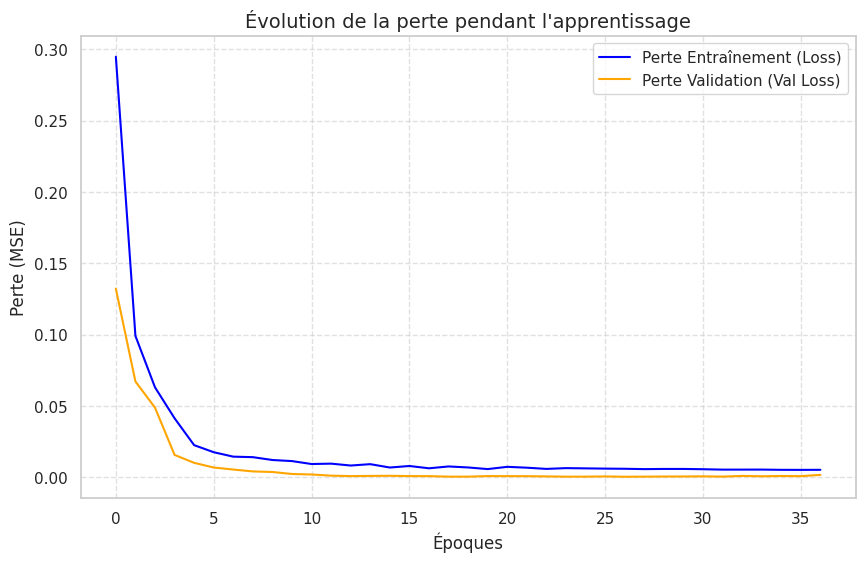

In [63]:
import matplotlib.pyplot as plt

# Configuration de la figure
plt.figure(figsize=(10, 6))

# Tracé des courbes de perte
plt.plot(history.history['loss'], label='Perte Entraînement (Loss)', color='blue')
plt.plot(history.history['val_loss'], label='Perte Validation (Val Loss)', color='orange')

# Personnalisation du graphique
plt.title("Évolution de la perte pendant l'apprentissage", fontsize=14)
plt.xlabel("Époques", fontsize=12)
plt.ylabel("Perte (MSE)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Affichage
plt.show()
